## Stage 1 – Data Validation

There is no guarantee that the data in the file is correctly formatted or that it matches the description.  
In the first stage, the following aspects should be verified:
- whether the data can be accessed,
- whether the number of records is appropriate,
- whether the data complies with the given specification.

In [6]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load the data

file_name = r'dice.csv'

try:
    data = pd.read_csv(file_name, header=None)
    print("Data has been successfully loaded.")
except Exception as e:
    print("Error during data loading:", e)

Data has been successfully loaded.


In [8]:
# Step 2: Verify the number of rows and columns

num_rows, num_cols = data.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

if num_rows == 70000 and num_cols == 786:
    print("The number of data entries is consistent with the description.")
else:
    print("WARNING: The number of data entries does NOT match the description!")

Number of rows: 70000
Number of columns: 786
The number of data entries is consistent with the description.


In [9]:
# Step 3: Label consistency (valid die and number of pips)

# Splitting into valid and invalid dice
correct_dice = data[data[0] == 1]  # valid dice
incorrect_dice = data[data[0] == 0]  # invalid dice

# Analysis of valid dice
print("--- Analysis of valid dice (column 0 == 1) ---")
correct_second_label = correct_dice[1]
correct_counts = correct_second_label.value_counts().sort_index()
print("\nNumber of pips (1-6):")
for number in range(1, 7):
    count = correct_counts.get(number, 0)
    print(f"{number} - {count}")
total_correct = correct_counts.sum()
print("Total number of valid dice:", total_correct)

# Analysis of invalid dice
print("\n--- Analysis of invalid dice (column 0 == 0) ---")
incorrect_second_label = incorrect_dice[1]
incorrect_counts = incorrect_second_label.value_counts().sort_index()
print("\nError codes (0-9):")
for number in range(10):
    count = incorrect_counts.get(number, 0)
    print(f"{number} - {count}")
total_incorrect = incorrect_counts.sum()
print("Total number of invalid dice:", total_incorrect)

--- Analysis of valid dice (column 0 == 1) ---

Number of pips (1-6):
1 - 10000
2 - 10000
3 - 10000
4 - 10000
5 - 10000
6 - 10000
Total number of valid dice: 60000

--- Analysis of invalid dice (column 0 == 0) ---

Error codes (0-9):
0 - 1002
1 - 976
2 - 1001
3 - 957
4 - 1025
5 - 952
6 - 1034
7 - 985
8 - 1062
9 - 1006
Total number of invalid dice: 10000


In [10]:
# Step 4: Check pixel value range (0-255)

pixels = data.iloc[:, 2:]
min_pixel_value = pixels.min().min()
max_pixel_value = pixels.max().max()
print(f"Pixel value range: {min_pixel_value} - {max_pixel_value}")
if 0 <= min_pixel_value <= 255 and 0 <= max_pixel_value <= 255:
    print("Pixel value range is valid.")
else:
    print("WARNING: Pixel value range is invalid!")

Pixel value range: 0 - 255
Pixel value range is valid.


In [11]:
# Step 5: Number of unique images

num_unique_images = len(data.iloc[:, 2:].drop_duplicates())
print(f"Number of unique images: {num_unique_images}")

Number of unique images: 70000


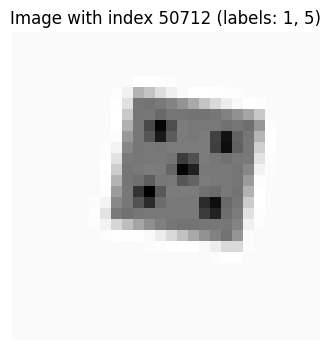

In [12]:
# Step 6: Visualizing a selected image

index_to_display = 120712 % 70000  
image_data = data.iloc[index_to_display, 2:].to_numpy().reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(image_data, cmap='gray')
plt.title(f"Image with index {index_to_display} (labels: {data.iloc[index_to_display, 0]}, {data.iloc[index_to_display, 1]})")
plt.axis('off')
plt.show()

### Description of Verification Methods and Results

1. **Data Loading Verification**  
- The data was loaded from a CSV file using the pandas library (pd.read_csv() method).  
- It was confirmed that the file was successfully loaded, indicated by the message "Data loaded successfully."

2. **Row and Column Count Verification**  
- The number of rows and columns in the dataset was checked using the .shape attribute.  
- Expected structure: 70,000 rows and 786 columns. These values were confirmed during the analysis.

3. **Label Consistency Verification**  
- The data was split into two categories: valid dice (label 1) and invalid dice (label 0).  
- For valid dice, it was verified that the number of dots (1 to 6) was evenly distributed (10,000 for each).  
- For invalid dice, the distribution of error types (0 to 9) was checked to confirm sufficient representation for each type.

4. **Pixel Value Range Verification**  
- It was confirmed that all pixel values fall within the expected grayscale range of 0 to 255.  
- All pixels were within this range, indicating the data is properly formatted.

5. **Unique Image Count Verification**  
- The number of unique images in the dataset was checked using the .drop_duplicates() function.  
- The result was 70,000 unique images, suggesting no duplicates are present in the dataset.

6. **Visualization of a Sample Image**  
- One image was selected and visualized.  
- The image was reshaped into a 2D array (28x28) and displayed using the matplotlib library. The corresponding labels were also shown.

## Stage 2 – Classification by Number of Dots

The goal of this stage is to develop an artificial neural network model that classifies images  
based on the number of dots on the top face of a valid die.

It is assumed that in both the training and test datasets (as well as in real-world usage),  
the input images may contain either valid or invalid dice.

The model output should be:
* If the die is invalid: detect and report it,
* If the die is valid: recognize the number of dots (from 1 to 6).

The primary evaluation metric is classification accuracy, which includes both:
- distinguishing valid from invalid dice,
- and correctly identifying the number of dots on valid dice.

GPU is not available - training on CPU 

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4018 - loss: 1.3925 - val_accuracy: 0.8933 - val_loss: 0.3123
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9418 - loss: 0.1923 - val_accuracy: 0.9923 - val_loss: 0.0392
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9835 - loss: 0.0582 - val_accuracy: 0.9964 - val_loss: 0.0176
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9915 - loss: 0.0303 - val_accuracy: 0.9976 - val_loss: 0.0099
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9840 - loss: 0.0525 - val_accuracy: 0.9964 - val_loss: 0.0125
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9924 - loss: 0.0253 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9936 - loss: 0.0222 - val_accuracy: 0.9946 - val_loss: 0.0155
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/ste

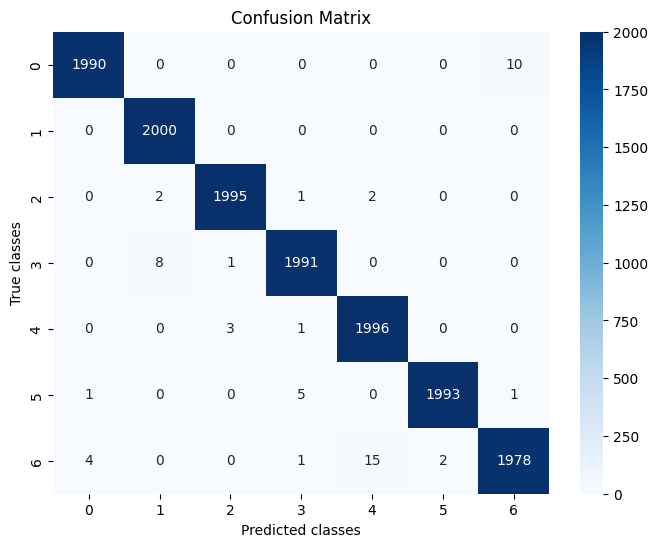


---------------

Model saved to 'model.keras'


In [ ]:
# Step 0: Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Step 1: Check and configure GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU detected: {physical_devices[0]} \n")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("GPU is not available - training on CPU \n")

# Step 2: Load data
file_name = r'dice.csv'
data = pd.read_csv(file_name, header=None)

# Step 3: Split into labels and image data
labels_primary = data.iloc[:, 0]  # Primary label: dice validity (0 - invalid / 1 - valid)
labels_secondary = data.iloc[:, 1]  # Secondary label: number of pips or error code
images = data.iloc[:, 2:].values  # Images: pixel values

# Step 4: Normalize pixel values (0-255 -> 0-1)
images = images.astype('float32') / 255.0

# Step 5: Reshape to 28x28x1 format
images = images.reshape(-1, 28, 28, 1)

# Step 6: Create labels
# Changing labels to 0-6: 0 for invalid dice / 1-6 for valid dice
final_labels = np.where(labels_primary == 1, labels_secondary, 0)

# Step 7: One-hot encoding of labels
num_classes = 7  # 7 classes: 0 - invalid dice, 1-6 - number of pips
labels_one_hot = to_categorical(final_labels, num_classes=num_classes)

# Step 8: Split into training (80%) and test (20%) sets, with stratified split for each class
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(images, final_labels):
    X_train, X_test = images[train_index], images[test_index]
    y_train, y_test = labels_one_hot[train_index], labels_one_hot[test_index]

# Step 9: Build the model
model = keras.Sequential([  # Sequential model
    keras.Input(shape=(28, 28, 1)),  # Input: 28x28x1 images
    layers.Conv2D(32, (3,3), activation='relu'),  # First layer
    layers.MaxPooling2D((2,2)),  # Reduces image dimensions while preserving important features
    layers.Conv2D(64, (3,3), activation='relu'),  # Second layer
    layers.MaxPooling2D((2,2)), # Reduces image dimensions while preserving important features
    layers.Conv2D(128, (3,3), activation='relu'),  # Third layer
    layers.Flatten(),  # Flattens the data to a one-dimensional vector
    layers.Dense(128, activation='relu'),  # Dense layer with 128 neurons
    layers.Dropout(0.3),  # Disables 30% of neurons in this layer
    layers.Dense(num_classes, activation='softmax', dtype='float32')  # Final output layer with 7 neurons
])

# Compile the model with Adam optimizer and categorical cross-entropy loss function
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 10: Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test))

# Step 11: Evaluate the model on the test set
print("\n---------------\n")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Model accuracy on the test set: {test_acc:.4f}')
print("\n---------------\n")

# Step 12: Predict results on the test set
y_pred = model.predict(X_test)

# Step 13: Convert predictions to classes (most likely class)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Step 14: Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(7), yticklabels=range(7))
plt.xlabel('Predicted classes')
plt.ylabel('True classes')
plt.title('Confusion Matrix')
plt.show()

# Step 15: Save the model to a file
model.save('model.keras')
print("\n---------------\n")
print("Model saved to 'model.keras'")

### **Description of the Applied Approach and Details of the Model Development Process**

The goal of the project was to develop an artificial neural network model for classifying images of dice.  
The model was designed to distinguish whether a die is valid, and if so, determine the number of dots on its top face.

The code development process consisted of several key stages:

- Loading the dataset and transforming it into a format suitable for model training.
- Preparing the labels using one-hot encoding to enable multi-class classification.
- Splitting the data into training and test sets to evaluate model performance.
- Building the neural network model with convolutional layers (Conv2D) and pooling layers (MaxPooling2D) to extract features from the images.
- Training the model on the training set and evaluating it on the test set.
- Analyzing the results and saving the trained model in Keras format.

### **Description of the Developed Model**

The developed model is a convolutional neural network (CNN) with the following structure:

1. **Input** – images in 28×28×1 format.
2. **Three convolutional layers (Conv2D)** – each with a 3×3 filter and ReLU activation. The first layer has 32 filters, the second one has 64, and the third one has 128. This allows for progressively capturing patterns in the image.
3. **Two pooling layers (MaxPooling2D)** – reduce the feature map dimensions, decreasing the number of computations and aiding in model generalization.
4. **Flatten** – transforms spatial data into a one-dimensional vector.
5. **Dense layer (128 neurons, ReLU activation)** – adds non-linearity, allowing the model to form more abstract representations.
6. **Dropout layer (0.3)** – disables 30% of neurons to prevent model overfitting.
7. **Output dense layer (7 neurons, softmax activation)** – predicts one of 7 classes.

Justification for the choices:

- **Convolutional layers** – they are standard in image processing and enable automatic pattern detection.
- **Pooling** – reduces dimensions and speeds up computations.
- **Dense layer** – allows for deeper understanding of image features.
- **Dropout** – prevents overfitting.
- **Softmax** – is the standard activation function for multi-class classification.

### **Results**

#### **Model Training**
The model was trained for 10 epochs, which allowed for an increase in accuracy and effective prevention of overfitting.

During model training (model.fit), Keras automatically calculates accuracy and loss for both the training and validation sets. The accuracy metric is measured as the ratio of correctly classified examples to all examples in the given set.

#### **Evaluation on the Test Set**
After training was completed, the model was evaluated on the test set using the model.evaluate() function, which calculates accuracy and loss. The final accuracy of the model on the test set is 99.59%, which indicates very high classification performance.

#### **Confusion Matrix**
To analyze the model's performance in more detail, a confusion matrix was used. It helps to see how often the model misclassifies, showing the number of misclassified instances for each class. In this case, the number of errors was minimal.